# Phase 3 - Tire Model Comparison

> Project Chrono / Vehicle / Wheeled  
> 목표: HMMWV 차량에서 tire model 변화가 주행 성능에 미치는 영향 비교

이번 실험은 같은 차량, 같은 지형, 같은 입력 조건에서 **타이어 모델만 바꾸어** 차량의 속도, 가속도, 궤적 응답을 비교한다.

비교 후보:

```text
Rigid Tire
Fiala Tire
TMeasy Tire
```

주의: PyChrono 설치 버전에 따라 일부 tire enum이 없을 수 있다. 이 노트북은 설치된 enum만 자동으로 찾아 실행하도록 구성했다.

## 1. Import

In [2]:
import os
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh

print("Chrono import success")
print("NumPy version:", np.__version__)

Chrono import success
NumPy version: 1.26.4


## 2. Path Setting

In [3]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3" / "tire_model_comparison"
FIGURE_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)

PROJECT_ROOT: C:\Users\lahee\Downloads
RESULT_DIR: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison


## 3. Simulation Parameters

In [4]:
veh.ChWorldFrame.SetYUP()

contact_method = chrono.ChContactMethod_NSC
step_size = 3e-3
tire_step_size = 1e-3
t_end = 12.0
terrain_friction = 0.9

fixed_steering = 0.0
fixed_throttle = 0.4
fixed_braking = 0.0

print("Simulation parameters ready")

Simulation parameters ready


## 4. Tire Model Cases

In [5]:
def get_available_tire_cases():
    candidates = [
        ("Rigid", "TireModelType_RIGID"),
        ("Fiala", "TireModelType_FIALA"),
        ("TMeasy", "TireModelType_TMEASY"),
        ("Pac89", "TireModelType_PAC89"),
        ("Pac02", "TireModelType_PAC02"),
    ]
    cases = []
    for label, enum_name in candidates:
        if hasattr(veh, enum_name):
            cases.append({
                "case_name": f"tire_{label.lower()}",
                "tire_label": label,
                "enum_name": enum_name,
                "tire_enum": getattr(veh, enum_name),
            })
    return cases

tire_cases = get_available_tire_cases()
print("Available tire model cases:")
for case in tire_cases:
    print(case["tire_label"], "->", case["enum_name"])
if len(tire_cases) == 0:
    raise RuntimeError("No tire model enum found. Check pychrono.vehicle tire enum names.")

Available tire model cases:
Rigid -> TireModelType_RIGID
Fiala -> TireModelType_FIALA
TMeasy -> TireModelType_TMEASY
Pac89 -> TireModelType_PAC89
Pac02 -> TireModelType_PAC02


## 5. Helper Functions

In [6]:
def get_chassis_body(hmmwv):
    vehicle = hmmwv.GetVehicle()
    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()
    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()
    raise RuntimeError("Could not access chassis body. Check PyChrono vehicle API.")

def safe_get_rpy_from_body(body):
    rot = body.GetRot()
    try:
        angles = rot.GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan

def get_vehicle_speed(hmmwv, body):
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)

def log_vehicle_state(hmmwv, driver_inputs, case_name, tire_label):
    system = hmmwv.GetSystem()
    body = get_chassis_body(hmmwv)
    time = float(system.GetChTime())
    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = safe_get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)
    return {
        "case_name": case_name, "tire_model": tire_label, "time": time,
        "x": float(pos.x), "y": float(pos.y), "z": float(pos.z),
        "vx": float(vel.x), "vy": float(vel.y), "vz": float(vel.z),
        "speed": speed, "roll": roll, "pitch": pitch, "yaw": yaw,
        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }

def add_derived_metrics(df_case):
    df_case = df_case.copy()
    time = df_case["time"].to_numpy()
    speed = df_case["speed"].to_numpy()
    if len(time) >= 2:
        df_case["acceleration"] = np.gradient(speed, time)
    else:
        df_case["acceleration"] = np.nan
    if not df_case["yaw"].isna().all() and len(time) >= 2:
        yaw = np.unwrap(df_case["yaw"].to_numpy())
        df_case["yaw_rate"] = np.gradient(yaw, time)
    else:
        df_case["yaw_rate"] = np.nan
    return df_case

print("Helper functions ready")

Helper functions ready


## 6. One Tire Case Simulation Function

In [7]:
def run_tire_case(case_name, tire_label, tire_enum):
    initLoc = chrono.ChVector3d(0, 1, 10)
    initYaw = 0.0

    hmmwv = veh.HMMWV_Reduced()
    hmmwv.SetContactMethod(contact_method)
    hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
    hmmwv.SetChassisFixed(False)
    hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))
    hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
    hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
    hmmwv.SetDriveType(veh.DrivelineTypeWV_AWD)
    hmmwv.SetTireType(tire_enum)
    hmmwv.SetTireStepSize(tire_step_size)
    hmmwv.Initialize()
    hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

    terrain = veh.RigidTerrain(hmmwv.GetSystem())
    patch_mat = chrono.ChContactMaterialNSC()
    patch_mat.SetFriction(terrain_friction)
    terrain.AddPatch(
        patch_mat,
        chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
        200.0, 100.0
    )
    terrain.Initialize()

    driver_inputs = veh.DriverInputs()
    driver_inputs.m_steering = fixed_steering
    driver_inputs.m_throttle = fixed_throttle
    driver_inputs.m_braking = fixed_braking

    log_rows = []
    while hmmwv.GetSystem().GetChTime() < t_end:
        time = hmmwv.GetSystem().GetChTime()
        log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name, tire_label))
        terrain.Synchronize(time)
        hmmwv.Synchronize(time, driver_inputs, terrain)
        terrain.Advance(step_size)
        hmmwv.Advance(step_size)

    return add_derived_metrics(pd.DataFrame(log_rows))

print("run_tire_case() ready")

run_tire_case() ready


## 7. Run Tire Model Cases

In [8]:
all_dfs = []

for case in tire_cases:
    print("Running:", case["case_name"], "using", case["enum_name"])
    try:
        df_case = run_tire_case(
            case_name=case["case_name"],
            tire_label=case["tire_label"],
            tire_enum=case["tire_enum"],
        )
        case_csv_path = RESULT_DIR / f'{case["case_name"]}.csv'
        df_case.to_csv(case_csv_path, index=False, encoding="utf-8-sig")
        print("Saved:", case_csv_path)
        all_dfs.append(df_case)
    except Exception as e:
        print("Failed:", case["case_name"])
        print("Reason:", e)

if len(all_dfs) == 0:
    raise RuntimeError("All tire model cases failed.")

df = pd.concat(all_dfs, ignore_index=True)
all_csv_path = RESULT_DIR / "tire_model_comparison_all_cases.csv"
df.to_csv(all_csv_path, index=False, encoding="utf-8-sig")
print("Saved combined CSV:", all_csv_path)
display(df.head())
display(df.tail())

Running: tire_rigid using TireModelType_RIGID
Saved: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_rigid.csv
Running: tire_fiala using TireModelType_FIALA
Saved: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_fiala.csv
Running: tire_tmeasy using TireModelType_TMEASY
Saved: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_tmeasy.csv
Running: tire_pac89 using TireModelType_PAC89
Saved: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_pac89.csv
Running: tire_pac02 using TireModelType_PAC02
Saved: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_pac02.csv
Saved combined CSV: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_model_comparison_all_cases.csv


,case_name,tire_model,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
0,tire_rigid,Rigid,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.4,0.0,-1.351101,-0.028312
1,tire_rigid,Rigid,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.4,0.0,-0.696926,-0.029179
2,tire_rigid,Rigid,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.4,0.0,0.039788,-0.029090
3,tire_rigid,Rigid,0.009,0.056019,1.212433,10.0,0.002153,-0.094368,-1.010458e-05,-0.003815,-1.570800,-1.003126e-08,-0.000259,0.0,0.4,0.0,0.120617,-0.027140
4,tire_rigid,Rigid,0.012,0.056025,1.212061,10.0,0.002069,-0.124009,-3.576578e-05,-0.003458,-1.570806,-2.787842e-08,-0.000338,0.0,0.4,0.0,0.121106,-0.025101


,case_name,tire_model,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
19995,tire_pac02,Pac02,11.985,107.648473,0.632248,8.550434,14.232355,-9.305699e-07,-0.208191,14.231004,-1.571343,0.014628,-0.020050,0.0,0.4,0.0,0.509179,-0.000067
19996,tire_pac02,Pac02,11.988,107.691174,0.632248,8.549809,14.233883,3.033403e-07,-0.208220,14.232530,-1.571343,0.014630,-0.020051,0.0,0.4,0.0,0.510497,-0.000073
19997,tire_pac02,Pac02,11.991,107.733881,0.632248,8.549184,14.235421,2.101349e-06,-0.208249,14.234067,-1.571343,0.014633,-0.020051,0.0,0.4,0.0,0.512857,-0.000077
19998,tire_pac02,Pac02,11.994,107.776591,0.632248,8.548560,14.236962,3.124795e-06,-0.208278,14.235607,-1.571344,0.014636,-0.020051,0.0,0.4,0.0,0.514871,-0.000077
19999,tire_pac02,Pac02,11.997,107.819307,0.632248,8.547935,14.238511,4.652331e-06,-0.208306,14.237156,-1.571344,0.014638,-0.020051,0.0,0.4,0.0,0.516123,-0.000077


## 8. Speed Response Comparison

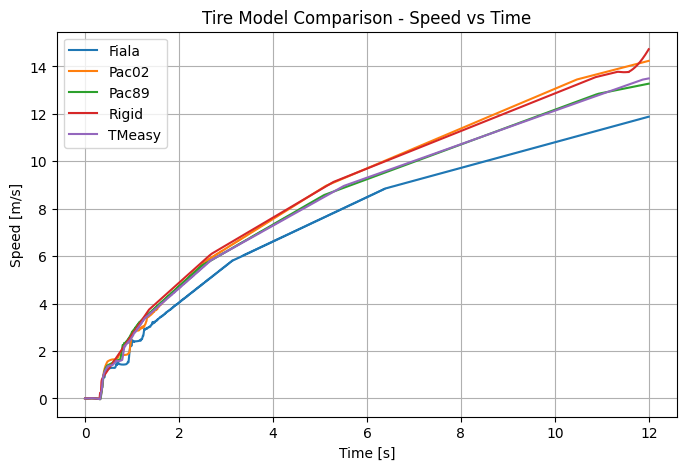

Saved figure: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\figures\tire_model_speed.png


In [9]:
plt.figure(figsize=(8, 5))
for tire_model, df_case in df.groupby("tire_model"):
    plt.plot(df_case["time"], df_case["speed"], label=tire_model)
plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Tire Model Comparison - Speed vs Time")
plt.grid(True)
plt.legend()
fig_path = FIGURE_DIR / "tire_model_speed.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

## 9. Acceleration Response Comparison

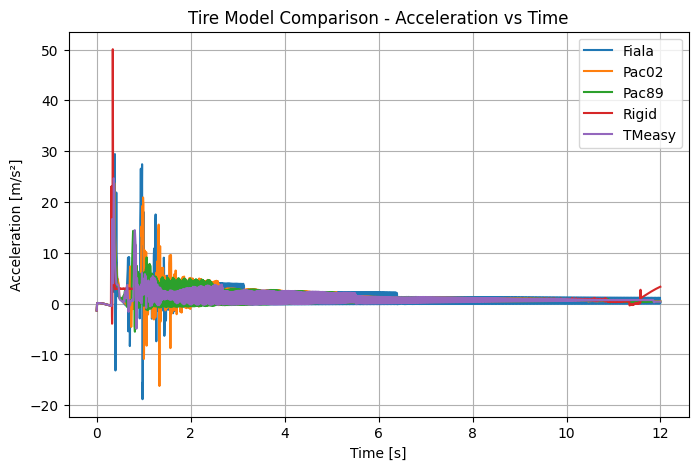

Saved figure: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\figures\tire_model_acceleration.png


In [10]:
plt.figure(figsize=(8, 5))
for tire_model, df_case in df.groupby("tire_model"):
    plt.plot(df_case["time"], df_case["acceleration"], label=tire_model)
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Tire Model Comparison - Acceleration vs Time")
plt.grid(True)
plt.legend()
fig_path = FIGURE_DIR / "tire_model_acceleration.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

## 10. X-Z Trajectory Comparison

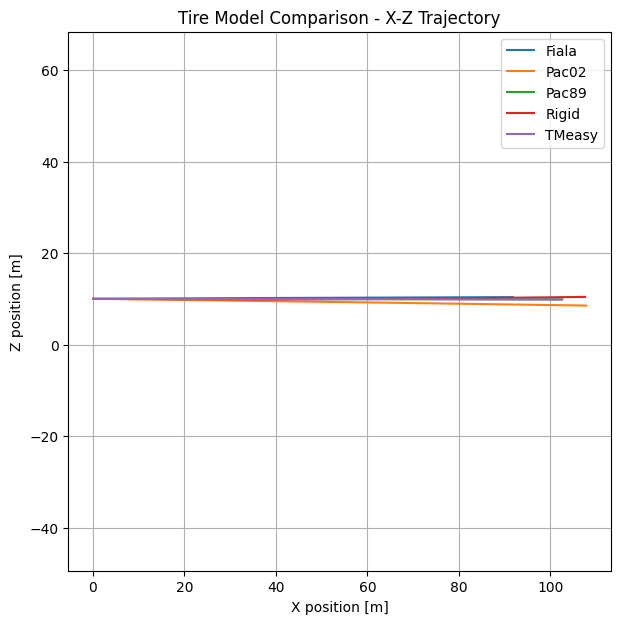

Saved figure: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\figures\tire_model_trajectory.png


In [11]:
plt.figure(figsize=(7, 7))
for tire_model, df_case in df.groupby("tire_model"):
    plt.plot(df_case["x"], df_case["z"], label=tire_model)
plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.title("Tire Model Comparison - X-Z Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
fig_path = FIGURE_DIR / "tire_model_trajectory.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

## 11. Summary Metrics

In [12]:
summary_rows = []
for tire_model, df_case in df.groupby("tire_model"):
    summary_rows.append({
        "tire_model": tire_model,
        "travel_x_m": df_case["x"].iloc[-1] - df_case["x"].iloc[0],
        "travel_z_m": df_case["z"].iloc[-1] - df_case["z"].iloc[0],
        "mean_speed_mps": df_case["speed"].mean(),
        "max_speed_mps": df_case["speed"].max(),
        "mean_acceleration_mps2": df_case["acceleration"].mean(),
        "max_acceleration_mps2": df_case["acceleration"].max(),
        "fixed_steering": fixed_steering,
        "fixed_throttle": fixed_throttle,
        "terrain_friction": terrain_friction,
    })
summary_df = pd.DataFrame(summary_rows)
summary_path = RESULT_DIR / "tire_model_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Saved summary:", summary_path)
display(summary_df)

Saved summary: C:\Users\lahee\Downloads\results\phase3\tire_model_comparison\tire_model_comparison_summary.csv


,tire_model,travel_x_m,travel_z_m,mean_speed_mps,max_speed_mps,mean_acceleration_mps2,max_acceleration_mps2,fixed_steering,fixed_throttle,terrain_friction
0,Fiala,91.738959,0.387004,7.642213,11.881372,0.989960,29.431259,0.0,0.4,0.9
1,Pac02,107.763307,-1.452065,8.977955,14.237156,1.186325,23.779185,0.0,0.4,0.9
2,Pac89,102.519643,-0.096418,8.540588,13.274423,1.106084,21.632184,0.0,0.4,0.9
3,Rigid,107.523267,0.441405,8.966612,14.727690,1.227554,50.062977,0.0,0.4,0.9
4,TMeasy,102.359288,-0.143907,8.527193,13.495987,1.124544,24.674419,0.0,0.4,0.9


## 12. Interpretation Guide

결과 해석 기준:

```text
1. 같은 throttle 조건에서도 tire model에 따라 speed/acceleration 응답이 달라지는지 확인한다.
2. Rigid tire는 단순 접촉 기반이라 빠르고 단순하다.
3. Fiala/TMeasy는 slip 기반 semi-empirical 모델이라 handling 특성이 더 잘 반영될 수 있다.
4. 결과가 거의 같다면 flat terrain + straight driving 조건에서는 tire model 차이가 크게 드러나지 않는다는 뜻이다.
   이 경우 다음 단계로 steering input 또는 low-friction terrain 조건을 추가해야 한다.
```